 # Environment Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42
SUBSET_STORES = ['CA_1', 'TX_1']  # keeps the hierarchy intact while bounding row count for Colab

print("Environment ready.")

Environment ready.


# Data Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

RAW_DIR = '/content/drive/MyDrive/Supply_Chain_Demand_Forecasting/data/raw/'

calendar = pd.read_csv(RAW_DIR + 'calendar.csv')
sell_prices = pd.read_csv(RAW_DIR + 'sell_prices.csv')

sales_wide = pd.read_csv(RAW_DIR + 'sales_train_evaluation.csv')
sales_wide = sales_wide[sales_wide['store_id'].isin(SUBSET_STORES)].reset_index(drop=True)

print(f"Calendar: {calendar.shape}")
print(f"Sell prices (full, pre-filter): {sell_prices.shape}")
print(f"Sales (wide, filtered to {SUBSET_STORES}): {sales_wide.shape}")
sales_wide.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Calendar: (1969, 14)
Sell prices (full, pre-filter): (6841121, 4)
Sales (wide, filtered to ['CA_1', 'TX_1']): (6098, 1947)


id        item_id    dept_id   cat_id store_id state_id  d_1  d_2  d_3  d_4  d_5  d_6  \
0  HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1       CA    0    0    0    0    0    0   
1  HOBBIES_1_002_CA_1_evaluation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1       CA    0    0    0    0    0    0   
2  HOBBIES_1_003_CA_1_evaluation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1       CA    0    0    0    0    0    0   
3  HOBBIES_1_004_CA_1_evaluation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1       CA    0    0    0    0    0    0   
4  HOBBIES_1_005_CA_1_evaluation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1       CA    0    0    0    0    0    0   

   d_7  d_8  d_9  d_10  d_11  d_12  d_13  d_14  d_15  d_16  d_17  d_18  d_19  d_20  d_21  d_22  d_23  d_24  d_25  \
0    0    0    0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0   
1    0    0    0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0   
2    0    0    0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0   
3    0    0    0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0   
4    0    0    0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0   

   d_26  d_27  d_28  d_29  d_30  d_31  d_32  d_33  d_34  d_35  d_36  d_37  d_38  d_39  d_40  d_41  d_42  d_43  d_44  \
0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     0     0     0     0     0     0     0     0     0     0     2     0     0     0     2     0     1     0   
4     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0   

   d_45  d_46  d_47  d_48  d_49  d_50  d_51  d_52  d_53  d_54  d_55  d_56  d_57  d_58  d_59  d_60  d_61  d_62  d_63  \
0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     0     0     0     0     2     0     1     0     0     1     1     1     0     2     3     1     0     0   
4     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0   

   d_64  d_65  d_66  d_67  d_68  d_69  d_70  d_71  d_72  d_73  d_74  d_75  d_76  d_77  d_78  d_79  d_80  d_81  d_82  \
0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     0     0     1     0     0     1     1     0     0     1     0     0     1     2     3     0     2     0   
4     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0   

   d_83  d_84  d_85  d_86  d_87  d_88  d_89  d_90  d_91  d_92  d_93  d_94  d_95  d_96  d_97  d_98  d_99  d_100  d_101  \
0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0      0      0   
1     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0      0      0   
2     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0      0

# Reshape: Wide → Long, then Merge Calendar and Price

In [ ]:
id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
day_cols = [c for c in sales_wide.columns if c.startswith('d_')]

sales_long = sales_wide.melt(
    id_vars=id_cols,
    value_vars=day_cols,
    var_name='d',
    value_name='units_sold'
)

print(f"Long format shape: {sales_long.shape}")
assert sales_long.shape[0] == sales_wide.shape[0] * len(day_cols), "Melt row count mismatch"
sales_long.head()

Long format shape: (11836218, 8)


,id,item_id,dept_id,cat_id,store_id,state_id,d,units_sold
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [ ]:
calendar_cols = ['d', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
                  'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
                  'snap_CA', 'snap_TX', 'snap_WI']

df = sales_long.merge(calendar[calendar_cols], on='d', how='left')

before = len(df)
df = df.merge(sell_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
assert len(df) == before, "Price merge changed row count — check for duplicate keys in sell_prices"

df['date'] = pd.to_datetime(df['date'])
print(f"Merged shape: {df.shape}")
df.head()

Merged shape: (11836218, 22)


,id,item_id,dept_id,cat_id,store_id,state_id,d,units_sold,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN


In [ ]:
def get_relevant_snap(row):
    return row[f'snap_{row["state_id"]}']

df['snap'] = df.apply(get_relevant_snap, axis=1)
df = df.drop(columns=['snap_CA', 'snap_TX', 'snap_WI'])

print("SNAP flag consolidated.")
df[['state_id', 'snap']].drop_duplicates().head()

SNAP flag consolidated.


,state_id,snap
0,CA,0
3049,TX,0
18294,CA,1
21343,TX,1


# Data Inspection

In [ ]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)

Shape: (11836218, 20)

Dtypes:
 id                      object
item_id                 object
dept_id                 object
cat_id                  object
store_id                object
state_id                object
d                       object
units_sold               int64
date            datetime64[ns]
wm_yr_wk                 int64
weekday                 object
wday                     int64
month                    int64
year                     int64
event_name_1            object
event_type_1            object
event_name_2            object
event_type_2            object
sell_price             float64
snap                     int64
dtype: object


In [ ]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11836218 entries, 0 to 11836217
Data columns (total 20 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            object        
 1   item_id       object        
 2   dept_id       object        
 3   cat_id        object        
 4   store_id      object        
 5   state_id      object        
 6   d             object        
 7   units_sold    int64         
 8   date          datetime64[ns]
 9   wm_yr_wk      int64         
 10  weekday       object        
 11  wday          int64         
 12  month         int64         
 13  year          int64         
 14  event_name_1  object        
 15  event_type_1  object        
 16  event_name_2  object        
 17  event_type_2  object        
 18  sell_price    float64       
 19  snap          int64         
dtypes: datetime64[ns](1), float64(1), int64(6), object(12)
memory usage: 7.3 GB


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report[missing_report['missing_count'] > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
event_name_2,11811826,99.79
event_type_2,11811826,99.79
event_name_1,10872734,91.86
event_type_1,10872734,91.86
sell_price,2249996,19.01


In [ ]:
key_dupes = df.duplicated(subset=['date', 'store_id', 'item_id']).sum()
print(f"Duplicate (date, store_id, item_id) rows: {key_dupes}")

Duplicate (date, store_id, item_id) rows: 0


In [ ]:
df[['units_sold', 'sell_price']].describe()

,units_sold,sell_price
count,1.183622e+07,9.586222e+06
mean,1.142685e+00,4.392686e+00
std,3.710766e+00,3.385360e+00
min,0.000000e+00,1.000000e-02
25%,0.000000e+00,2.180000e+00
50%,0.000000e+00,3.440000e+00
75%,1.000000e+00,5.780000e+00
max,6.480000e+02,5.262000e+01


In [ ]:
for c in ['cat_id', 'dept_id', 'store_id', 'state_id']:
    print(f"{c}: {df[c].nunique()} unique -> {sorted(df[c].unique())}")

cat_id: 3 unique -> ['FOODS', 'HOBBIES', 'HOUSEHOLD']
dept_id: 7 unique -> ['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']
store_id: 2 unique -> ['CA_1', 'TX_1']
state_id: 2 unique -> ['CA', 'TX']


# Data Cleaning

In [ ]:
df_clean = df.copy()

# 4.1 Sort chronologically within each (store, item) series
# Required before ANY lag/rolling feature -- wrong order silently corrupts every later feature.
df_clean = df_clean.sort_values(['store_id', 'item_id', 'date']).reset_index(drop=True)

print("Sorted. Shape unchanged:", df_clean.shape)

Sorted. Shape unchanged: (11836218, 20)


In [ ]:
# 4.2 Missing sell_price
# WHY: M5 has genuine structural missingness here -- price is missing for weeks before an item was
# actually stocked at a given store (it didn't exist there yet), not a data error to impute blindly.
# We forward-fill within each (store, item) series (price is stable day-to-day), then DROP rows still
# missing after that -- those are weeks the item genuinely wasn't sold at that store.
df_clean['sell_price'] = df_clean.groupby(['store_id', 'item_id'])['sell_price'].ffill()

before = len(df_clean)
df_clean = df_clean.dropna(subset=['sell_price'])
print(f"Dropped {before - len(df_clean)} rows with no valid price (item not yet listed at that store).")

Dropped 2249996 rows with no valid price (item not yet listed at that store).


In [ ]:
# 4.3 Event columns: NaN legitimately means "no event that day" -- not missing data.
for c in ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']:
    df_clean[c] = df_clean[c].fillna('none')

print("Event columns filled. Remaining nulls in event columns:",
      df_clean[['event_name_1','event_type_1','event_name_2','event_type_2']].isnull().sum().sum())

Event columns filled. Remaining nulls in event columns: 0


In [ ]:
# 4.4 Units sold cannot be negative
n_negative = (df_clean['units_sold'] < 0).sum()
print(f"Negative units_sold rows: {n_negative}")

if n_negative > 0:
    df_clean = df_clean[df_clean['units_sold'] >= 0]

print("\nFinal cleaned shape:", df_clean.shape)

Negative units_sold rows: 0

Final cleaned shape: (9586222, 20)


In [ ]:
# 4.5 Zero-sales streaks -- FLAG, do not drop
# A run of zero sales can mean genuine no-demand OR an out-of-stock day where demand existed but
# couldn't be fulfilled. Treating all zeros as "true zero demand" biases the model to under-forecast
# after stockouts. We flag now and revisit this explicitly in Item #9 (features) and Item #15 (error analysis).
df_clean['is_zero_sale'] = (df_clean['units_sold'] == 0).astype(int)

zero_rate_by_item = df_clean.groupby('item_id')['is_zero_sale'].mean().sort_values(ascending=False)
print("Items with highest zero-sale rate (candidates for stockout investigation):")
print(zero_rate_by_item.head(10))

Items with highest zero-sale rate (candidates for stockout investigation):
item_id
HOBBIES_2_119      0.973544
FOODS_1_079        0.964043
HOUSEHOLD_2_245    0.963589
HOBBIES_1_302      0.962117
HOUSEHOLD_2_087    0.959772
HOBBIES_1_212      0.956590
HOUSEHOLD_2_042    0.954405
FOODS_1_084        0.954147
HOBBIES_2_079      0.952156
HOUSEHOLD_2_278    0.951302
Name: is_zero_sale, dtype: float64


#Exploratory Data Analysis


Overall Demand Trend

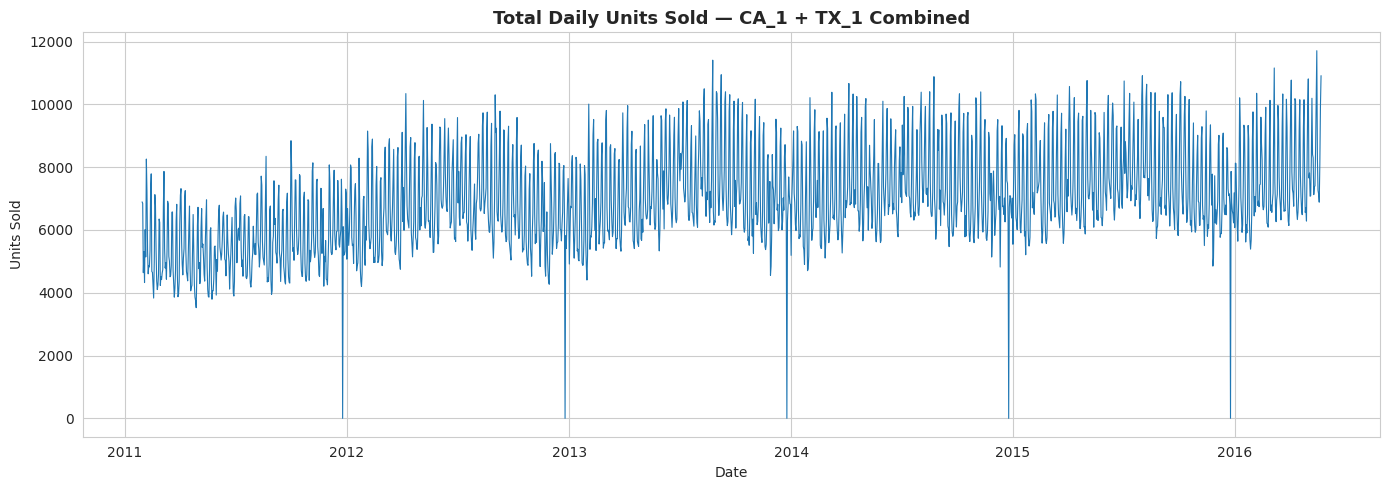

In [ ]:
daily_demand = df_clean.groupby('date')['units_sold'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_demand['date'], daily_demand['units_sold'], linewidth=0.8)
plt.title('Total Daily Units Sold — CA_1 + TX_1 Combined')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

Weekly Seasonality

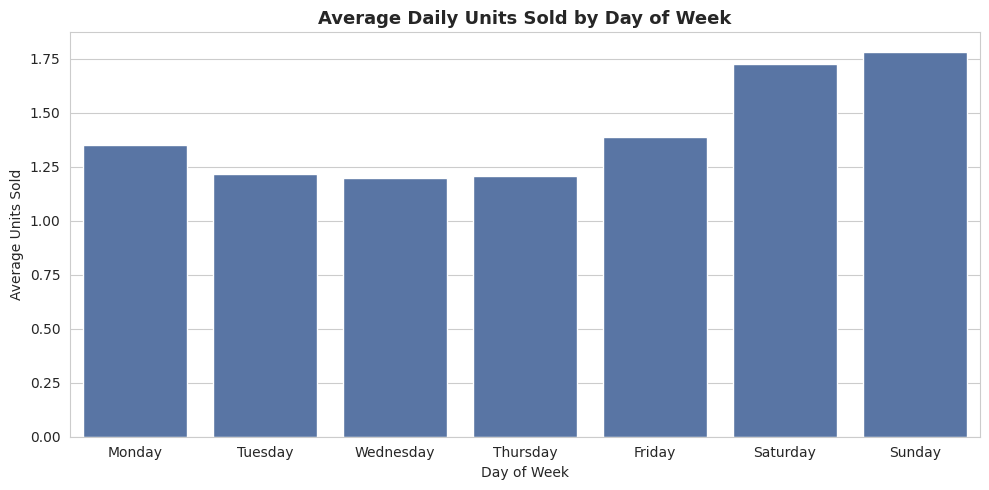

In [ ]:
df_clean['day_name'] = df_clean['date'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_demand = df_clean.groupby('day_name')['units_sold'].mean().reindex(dow_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=dow_demand.index, y=dow_demand.values, color='#4C72B0')
plt.title('Average Daily Units Sold by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Units Sold')
plt.tight_layout()
plt.show()

Monthly / Annual Seasonality

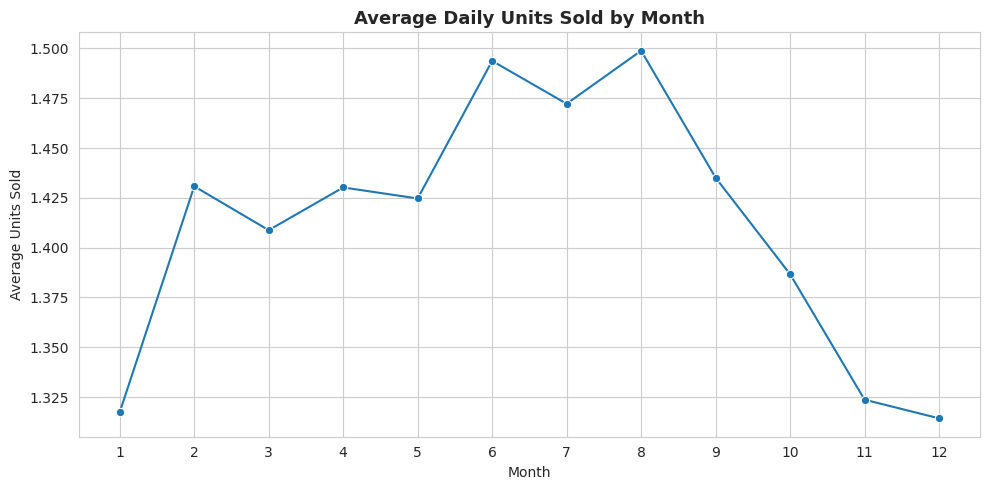

In [ ]:
monthly_demand = df_clean.groupby('month')['units_sold'].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_demand.index, y=monthly_demand.values, marker='o')
plt.title('Average Daily Units Sold by Month')
plt.xlabel('Month')
plt.ylabel('Average Units Sold')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

 Demand by Category and Department

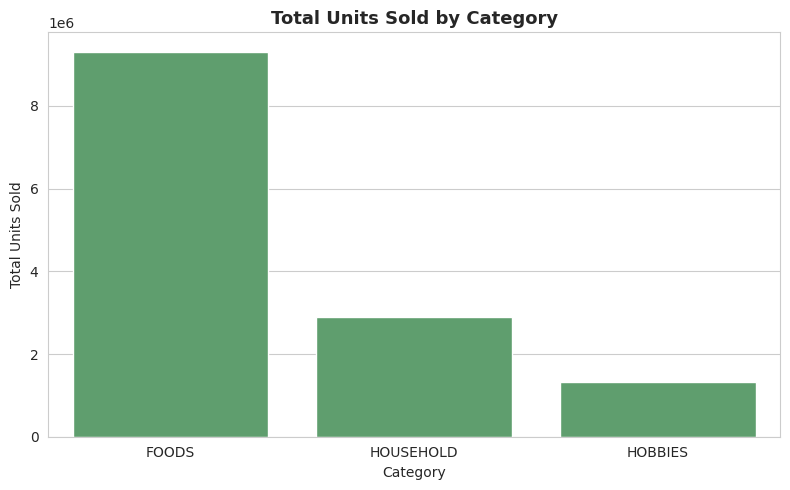

In [ ]:
cat_demand = df_clean.groupby('cat_id')['units_sold'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=cat_demand.index, y=cat_demand.values, color='#55A868')
plt.title('Total Units Sold by Category')
plt.xlabel('Category')
plt.ylabel('Total Units Sold')
plt.tight_layout()
plt.show()

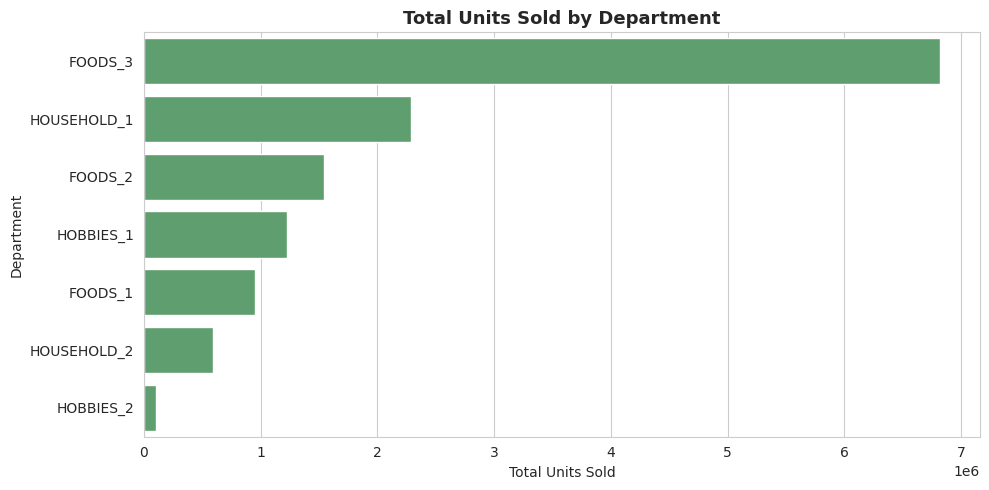

In [ ]:
dept_demand = df_clean.groupby('dept_id')['units_sold'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=dept_demand.values, y=dept_demand.index, color='#55A868')
plt.title('Total Units Sold by Department')
plt.xlabel('Total Units Sold')
plt.ylabel('Department')
plt.tight_layout()
plt.show()

Store / State Comparison

              sum      mean
store_id                   
CA_1      7832248  1.635717
TX_1      5692823  1.186510


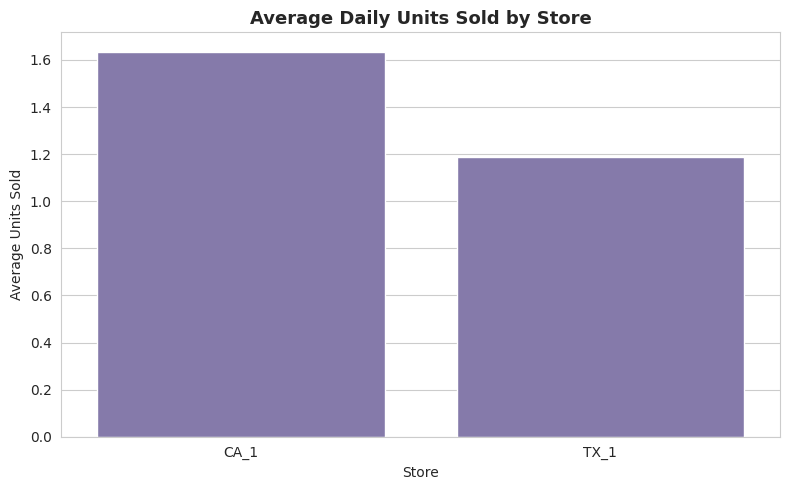

In [ ]:
store_demand = df_clean.groupby('store_id')['units_sold'].agg(['sum', 'mean'])
print(store_demand)

plt.figure(figsize=(8, 5))
sns.barplot(x=store_demand.index, y=store_demand['mean'], color='#8172B2')
plt.title('Average Daily Units Sold by Store')
plt.xlabel('Store')
plt.ylabel('Average Units Sold')
plt.tight_layout()
plt.show()

Price vs. Demand

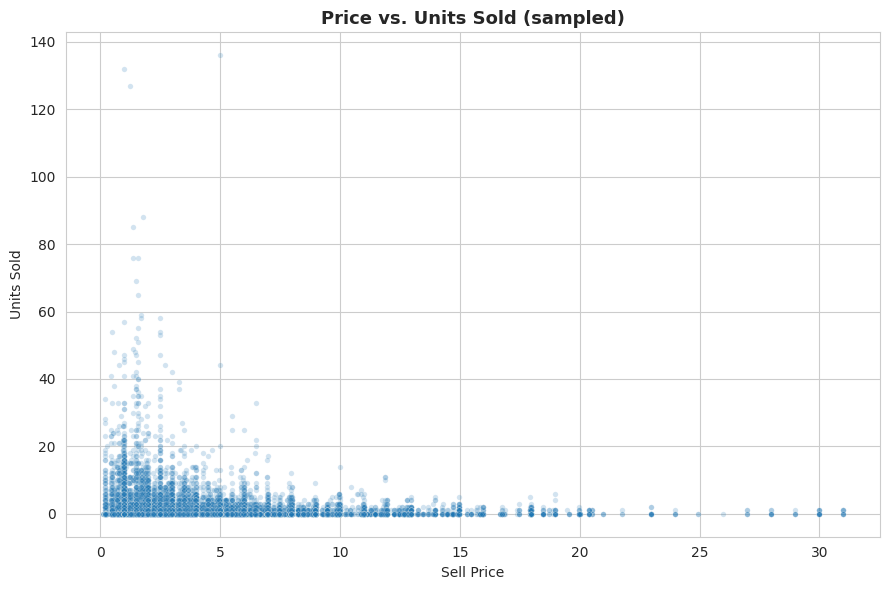

In [ ]:
sample = df_clean.sample(min(20000, len(df_clean)), random_state=RANDOM_STATE)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=sample, x='sell_price', y='units_sold', alpha=0.2, s=15)
plt.title('Price vs. Units Sold (sampled)')
plt.xlabel('Sell Price')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

SNAP (Promotion-like) Effect

snap
0    1.360116
1    1.514373
Name: units_sold, dtype: float64

Estimated SNAP-day demand lift: 11.3%


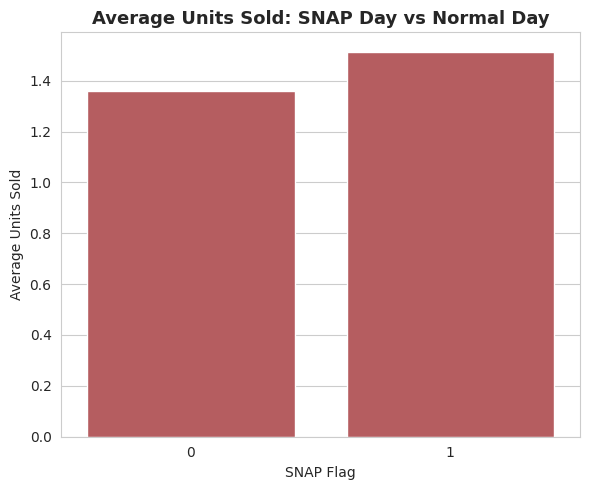

In [ ]:
snap_effect = df_clean.groupby('snap')['units_sold'].mean()
print(snap_effect)

lift_pct = (snap_effect.get(1, np.nan) / snap_effect.get(0, np.nan) - 1) * 100
print(f"\nEstimated SNAP-day demand lift: {lift_pct:.1f}%")

plt.figure(figsize=(6, 5))
sns.barplot(x=snap_effect.index.astype(str), y=snap_effect.values, color='#C44E52')
plt.title('Average Units Sold: SNAP Day vs Normal Day')
plt.xlabel('SNAP Flag')
plt.ylabel('Average Units Sold')
plt.tight_layout()
plt.show()

Special Event Effect

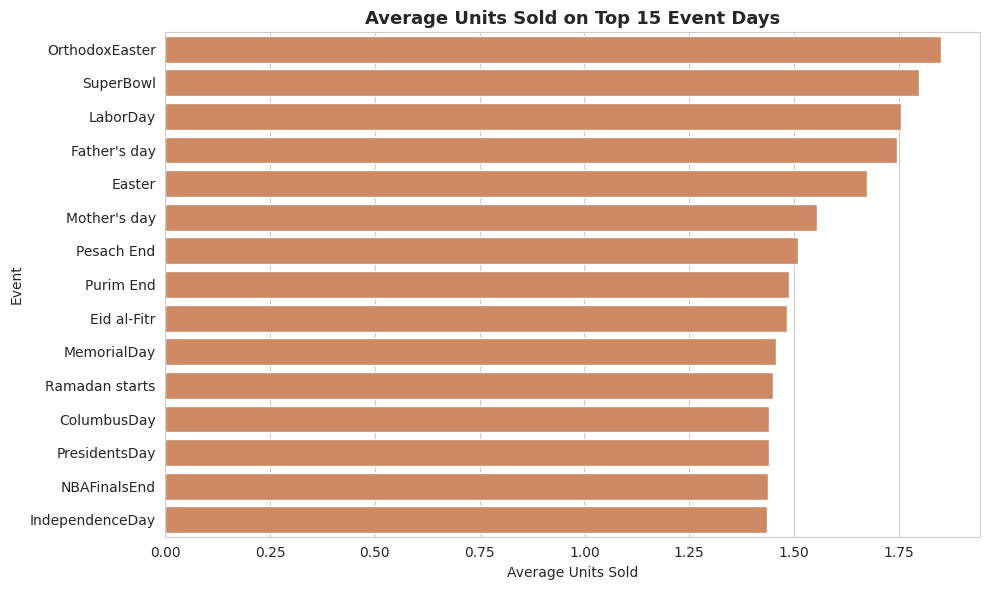

In [ ]:
event_effect = (
    df_clean[df_clean['event_name_1'] != 'none']
    .groupby('event_name_1')['units_sold']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=event_effect.values, y=event_effect.index, color='#DD8452')
plt.title('Average Units Sold on Top 15 Event Days')
plt.xlabel('Average Units Sold')
plt.ylabel('Event')
plt.tight_layout()
plt.show()

Distribution & Outlier View

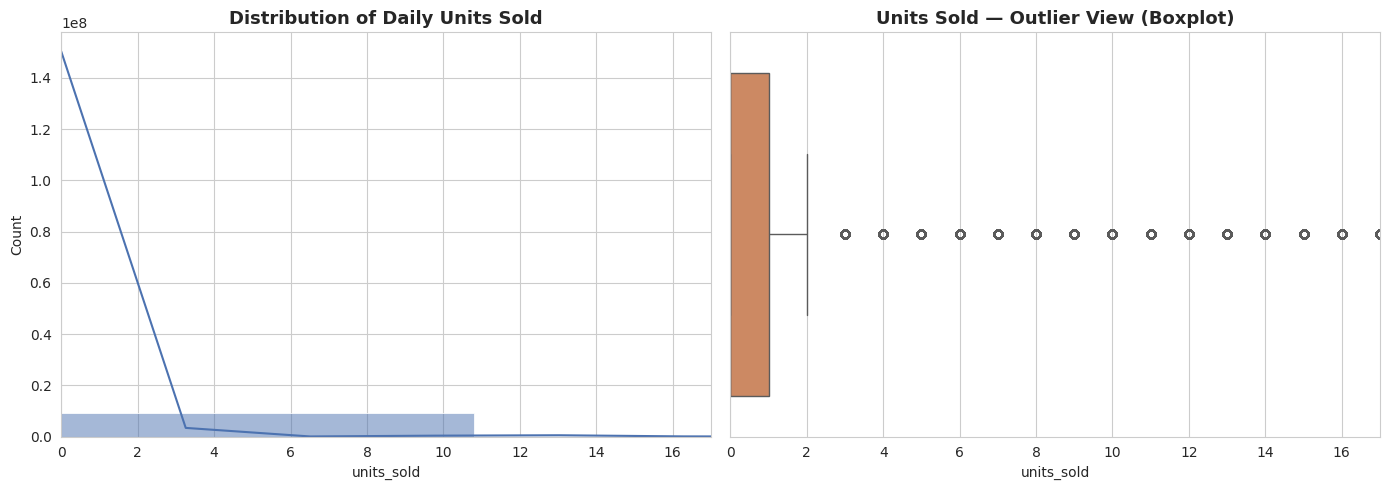

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean['units_sold'], bins=60, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Daily Units Sold')
axes[0].set_xlim(0, df_clean['units_sold'].quantile(0.99))

sns.boxplot(x=df_clean['units_sold'], ax=axes[1], color='#DD8452')
axes[1].set_title('Units Sold — Outlier View (Boxplot)')
axes[1].set_xlim(0, df_clean['units_sold'].quantile(0.99))

plt.tight_layout()
plt.show()

Correlation Heatmap

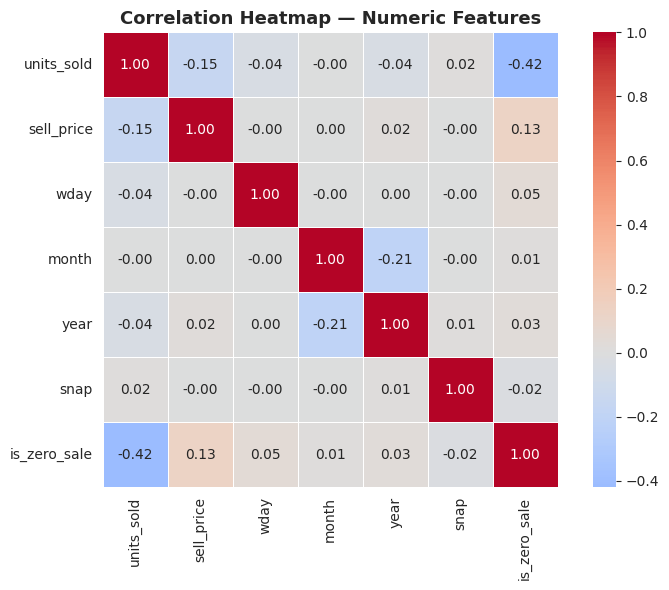

In [ ]:
numeric_for_corr = df_clean[['units_sold', 'sell_price', 'wday', 'month', 'year', 'snap', 'is_zero_sale']]
corr = numeric_for_corr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

#Save Cleaned Output

In [ ]:
OUT_PATH = "/content/drive/MyDrive/Supply_Chain_Demand_Forecasting/data/processed/cleaned_sales_data.csv"

df_clean.to_csv(OUT_PATH, index=False)
print("Saved cleaned_sales_data.csv —", df_clean.shape)

Saved cleaned_sales_data.csv — (9586222, 22)


## Key Takeaways

###Successfully transformed the M5 dataset from wide to long format.
###Merged calendar and price information into a unified dataset.
###Identified missing values and handled them appropriately.
###Explored sales patterns across stores, categories, and events.
###Saved the cleaned dataset for subsequent analysis and modeling.